<a href="https://colab.research.google.com/github/lucasribs/Aula26/blob/main/Aula_LSTM_IME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Implementação de LSTM com Keras 3: Guia Técnico

Este notebook demonstra como carregar dados climáticos e construir uma rede neural Long Short-Term Memory (LSTM) para previsão de séries temporais.

##1. Configuração das Bibliotecas e Carregamento de Dados
O primeiro passo é importar as bibliotecas necessárias e carregar o conjunto de dados. Para redes neurais, é essencial que os dados sejam escalonados para garantir a convergência do modelo

In [22]:
import numpy as np
import pandas as pd #Trabalhar com matrizes
import matplotlib.pyplot as plt #plotar gráficos

from sklearn.preprocessing import MinMaxScaler #pré-processamento
from sklearn.metrics import mean_squared_error, mean_absolute_error

from keras.models import Sequential #combinar camadas
from keras.layers import Dense, LSTM, Dropout #camadas diferentes
from keras.utils import plot_model #apresentar a arquitetura da solução
from keras.callbacks import EarlyStopping

In [23]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "DailyDelhiClimateTrain.csv"

# Load the latest version
serie = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sumanthvrao/daily-climate-time-series-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", serie.head())

Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.
First 5 records:          date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


##2. Análise Exploratória dos Dados e Preparação

In [24]:
serie['date'] = pd.to_datetime(serie['date'])

serie = serie.sort_values('date')

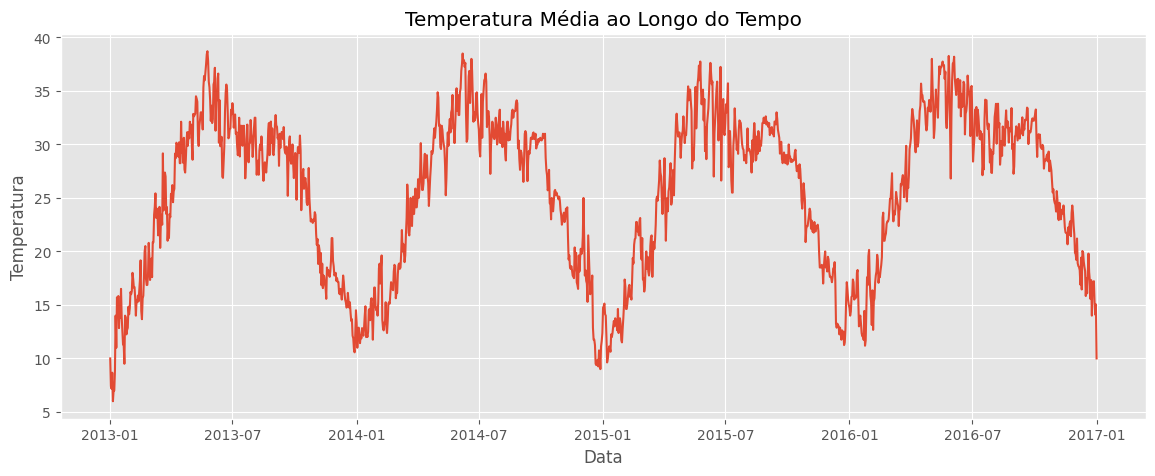

In [25]:
plt.figure(figsize=(14,5))

plt.plot(serie['date'], serie['meantemp'])

plt.title('Temperatura Média ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Temperatura')

plt.show()


In [26]:
dados = serie['meantemp'].values

dados = dados.reshape(-1,1)
scaler = MinMaxScaler(feature_range=(0,1))

dados_normalizados = scaler.fit_transform(dados)

##3. Preparação dos Dados para LSTM
Diferente de modelos lineares, as camadas LSTM no Keras exigem uma entrada em formato 3D: [batch_size, timesteps, dimensionality].

* Timesteps: É a "janela" de tempo (ou input_size) que o modelo observa.
* Dimensionality: Número de atributos (no caso de série univariada, é 1).

In [27]:
window_size = 30

def criar_sequencias(dataset, janela):
    X = []
    y = []

    for i in range(len(dataset) - janela):
        X.append(dataset[i:(i + janela), 0])
        y.append(dataset[i + janela, 0])

    return np.array(X), np.array(y)

X, y = criar_sequencias(dados_normalizados, window_size)

X.shape, y.shape


((1432, 30), (1432,))

##4. Split dos dados
Atenção à dataleakage.

In [28]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

# Contiguous split for time series
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size : train_size + val_size]
y_val = y[train_size : train_size + val_size]

X_test = X[train_size + val_size :]
y_test = y[train_size + val_size :]

In [29]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1)) # Reshape X_val
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

X_train.shape

(1002, 30, 1)

##5. Arquitetura da Rede LSTM

Utilizaremos a API Sequential do Keras para empilhar as camadas. Ao empilhar múltiplas camadas LSTM, é obrigatório definir return_sequences=True em todas, exceto na última camada recorrente.

In [106]:
modelo = Sequential()

modelo.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)#,
        # dropout = 0.1
    )
)

# modelo.add(LSTM(units=32, dropout=0.1))
modelo.add(LSTM(units=32))

modelo.add(Dropout(0.2))

modelo.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [97]:
modelo.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [98]:
modelo.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

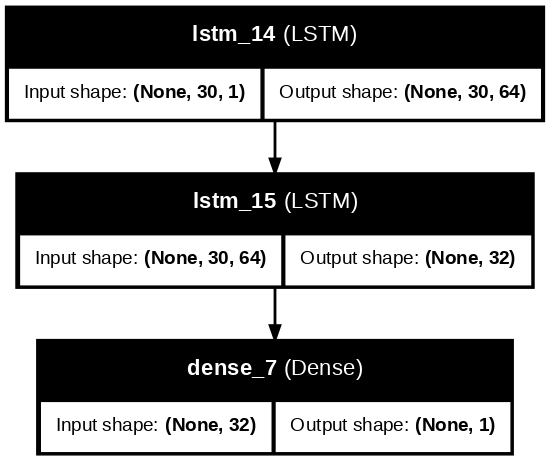

In [99]:
# pip install pydot graphviz

plot_model(
    modelo,
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

In [100]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [101]:
historico = modelo.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0381 - val_loss: 0.0084
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0055 - val_loss: 0.0056
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0051 - val_loss: 0.0068
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0050 - val_loss: 0.0050
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0046 - val_loss: 0.0046
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0043 - val_loss: 0.0044
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0042 - val_loss: 0.0050
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step

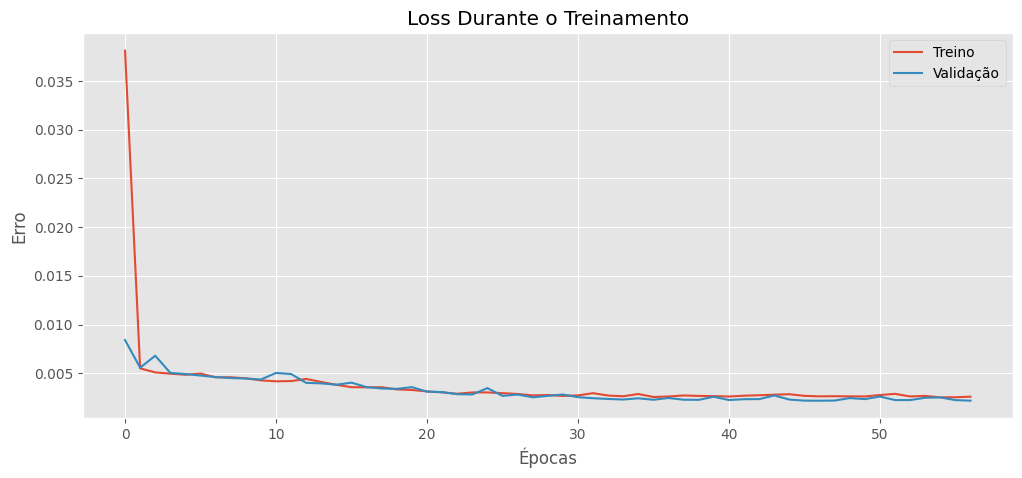

In [102]:
plt.figure(figsize=(12,5))

plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='Validação')

plt.title('Loss Durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Erro')

plt.legend()

plt.show()

In [103]:
predicoes = modelo.predict(X_test)

predicoes = scaler.inverse_transform(predicoes)

y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


##6. Avaliação
Após o treinamento, o modelo pode ser usado para prever valores futuros. É recomendado comparar os resultados com métricas como o WMAPE (Weighted Mean Absolute Percentage Error) para uma avaliação mais robusta em séries reais

In [104]:
rmse = np.sqrt(mean_squared_error(y_test_real, predicoes))
mae = mean_absolute_error(y_test_real, predicoes)

erro_absoluto = abs(y_test_real - predicoes)
soma_erro = sum(erro_absoluto)[0]
soma_real = sum(y_test_real)[0]
wmape = (soma_erro / soma_real) * 100.0


print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'WMAPE: {wmape:.2f}')

RMSE: 1.53
MAE: 1.16
WMAPE: 4.12


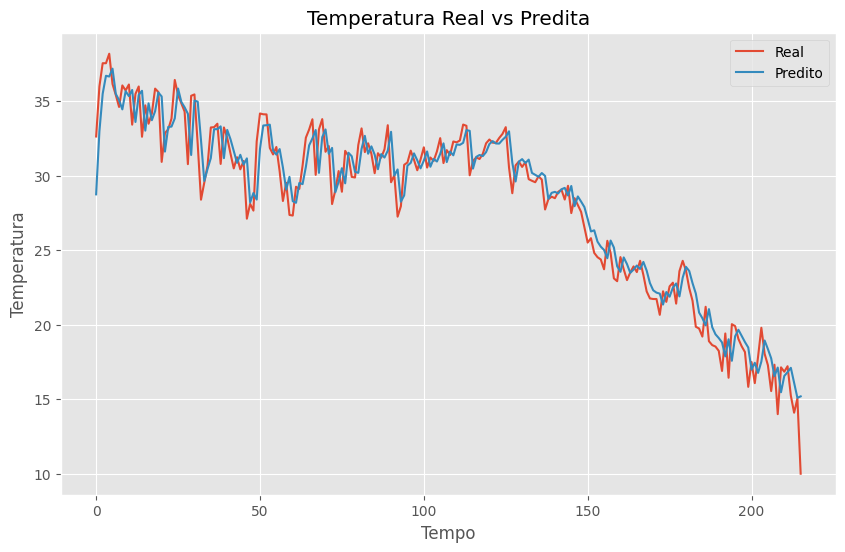

In [105]:
plt.figure(figsize=(10,6))

plt.plot(y_test_real, label='Real')
plt.plot(predicoes, label='Predito')

plt.title('Temperatura Real vs Predita')
plt.xlabel('Tempo')
plt.ylabel('Temperatura')

plt.legend()

plt.show()

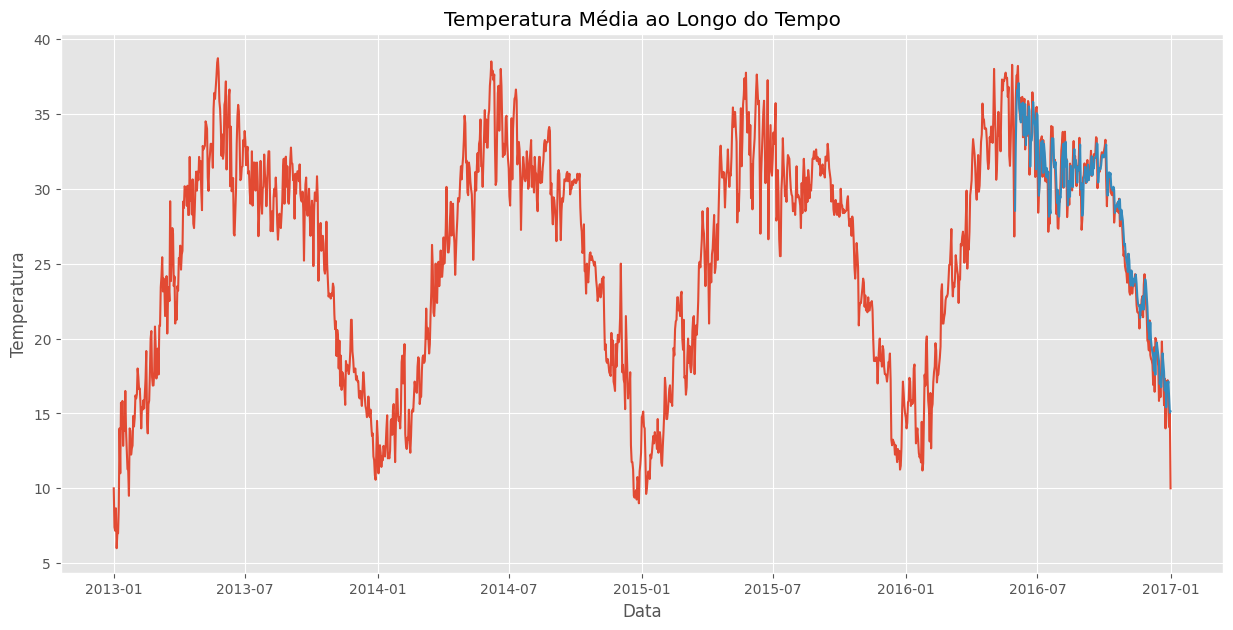

In [85]:
plt.figure(figsize=(15,7))

plt.plot(serie['date'], serie['meantemp'])
plt.plot(serie['date'][-y_test.shape[0]:], predicoes)

plt.title('Temperatura Média ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Temperatura')

plt.show()